In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
from more_itertools.more import is_sorted
from torch.nn.functional import cosine_similarity

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [ ]:
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

In [ ]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0091_m6Afinal/pileup_strid.npz.geneid.pkl"
hela_df = pd.read_pickle(hela_df).reset_index(drop=True)
hela_df = hela_df[hela_df["count_all"] >= 20]
print(hela_df)

hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz.geneid.pkl"
hek_df = pd.read_pickle(hek_df).reset_index(drop=True)
hek_df = hek_df[hek_df["count_all"] >= 20]
print(hek_df)

In [ ]:
## get m6a pos for each refseq
hek_fdr_threshold = 0.61
hela_fdr_threshold = 0.64

In [ ]:
hela_df["chr"] = hela_df["genome_id"].str.split(":").str[0]
hek_df["chr"] = hek_df["genome_id"].str.split(":").str[0]
hela_df["strand"] = hela_df["genome_id"].str.split(":").str[1]
hek_df["strand"] = hek_df["genome_id"].str.split(":").str[1]
hela_df["genome_pos"] = hela_df["genome_id"].str.split(":").str[2].astype(int)
hek_df["genome_pos"] = hek_df["genome_id"].str.split(":").str[2].astype(int)

In [ ]:
hela_df["dmgval"] = hela_df["dom"] * (hela_df["pm6a"] > hela_fdr_threshold).astype(int)
hek_df["dmgval"] = hek_df["dom"] * (hek_df["pm6a"] > hek_fdr_threshold).astype(int)

In [ ]:
hela_df_groupby_gene = hela_df.groupby("gene_id")
hek_df_groupby_gene = hek_df.groupby("gene_id")

## DMG search

In [ ]:
merged_exon = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/anno/merged_exons.pkl")
merged_exon = merged_exon.set_index("gene_id")

In [ ]:
def genomic_to_exonic(query, exonstarts, exonends, strand):
    ## assert sorted
    assert (query[1:] >= query[:-1]).all()
    current_exon_idx = 0
    past_exons_sum = 0
    exonlengths = exonends - exonstarts
    exonlengths_sum = exonlengths.sum()
    exonic_query = np.zeros_like(query)
    for i, current_query in enumerate(query):
        while current_query >= exonends[current_exon_idx]:
            past_exons_sum += exonlengths[current_exon_idx]
            current_exon_idx += 1
        exonic_current_query = current_query - exonstarts[current_exon_idx] + past_exons_sum
        exonic_query[i] = exonic_current_query
    if strand == "-":
        exonic_query = exonlengths_sum - exonic_query - 1
    return exonic_query /exonlengths_sum

In [ ]:
def get_dmg_arr(df1, df2, gene_id, merged_exon):
    assert df1["chr"].nunique() == 1
    assert df1["strand"].nunique() == 1
    assert df2["chr"].nunique() == 1
    assert df2["strand"].nunique() == 1
    assert df1["chr"].values[0] == df2["chr"].values[0]
    assert df1["strand"].values[0] == df2["strand"].values[0] 
    merged = df1[["genome_pos","drach","dmgval"]].merge(df2[["genome_pos","dmgval"]], on="genome_pos", how="outer", suffixes=("_1","_2")).dropna()
    merged = merged.sort_values("genome_pos")
    gene_row = merged_exon.loc[gene_id]
    merged["exonic_pos"] = genomic_to_exonic(merged["genome_pos"].values, gene_row["exonStarts"], gene_row["exonEnds"], gene_row["strand"])
    if gene_row["strand"] == "-":
        return merged[["dmgval_1","dmgval_2","exonic_pos","drach"]].values[::-1]
    else:
        return merged[["dmgval_1","dmgval_2","exonic_pos","drach"]].values


In [ ]:
common_gene_ids = np.intersect1d(hela_df["gene_id"].unique(), hek_df["gene_id"].unique())
dmg_dict = {}
for gene_id in tqdm.tqdm(common_gene_ids):
    hela_df_gene = hela_df_groupby_gene.get_group(gene_id)
    hek_df_gene = hek_df_groupby_gene.get_group(gene_id)
    dmg_arr = get_dmg_arr(hek_df_gene, hela_df_gene, gene_id, merged_exon)
    if len(dmg_arr) > 0:
        dmg_dict[gene_id] = dmg_arr
print(len(dmg_dict))
import pickle
with open("/extdata4/baeklab/Hyeonseo/m6A/analyses/dmg/dmg_dict.pkl", "wb") as f:
    pickle.dump(dmg_dict, f)
    

## Plotting


In [ ]:
def plot_dmg_arr(title, dmg_arr, colour="cell", output = "/extdata4/baeklab/Hyeonseo/m6A/plot/dmg"):
    ## colour: cell, dynamic, drach

    cell_colours = ["royalblue", "tomato"]
    dynamic_colours = ["#EF962C", "#7652E3"]
    drach_colours = ["#808080", "#D7432E"]

    fig, ax = plt.subplots(figsize=(20,10))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)
    ax.set_yticks(list(np.arange(-1,1.1,0.25)))
    ax.set_yticklabels([f"{x:.2f}" for x in np.arange(-1,1.1,0.25)])
    ax.grid()

    barwidth = 0.01
    
    if colour == "cell":
        union = (dmg_arr.sum(axis=1) > 0)
        ax.bar(dmg_arr[union,2], dmg_arr[union,0], color=cell_colours[0], width=barwidth, label="HEK293T")
        ax.bar(dmg_arr[union,2], -dmg_arr[union,1], color=cell_colours[1], width=barwidth, label="HeLa")
        
    elif colour == "dynamic":
        union = (dmg_arr.sum(axis=1) > 0)
        static = (dmg_arr[:,0] * dmg_arr[:,1] > 0)
        dynamic = union & ~static
        ax.bar(dmg_arr[static,2], dmg_arr[static,0], color=dynamic_colours[0], width=barwidth, label="Static")
        ax.bar(dmg_arr[static,2], -dmg_arr[static,1], color=dynamic_colours[0], width=barwidth)
        ax.bar(dmg_arr[dynamic,2], dmg_arr[dynamic,0], color=dynamic_colours[1], width=barwidth, label="Dynamic")
        ax.bar(dmg_arr[dynamic,2], -dmg_arr[dynamic,1], color=dynamic_colours[1], width=barwidth)
        
    elif colour == "drach":
        drach_arr = dmg_arr[:,3].astype(bool)
        ax.bar(dmg_arr[drach_arr,2], dmg_arr[drach_arr,0], color=drach_colours[0], width=barwidth, label="DRACH")
        ax.bar(dmg_arr[drach_arr,2], -dmg_arr[drach_arr,1], color=drach_colours[0], width=barwidth)
        ax.bar(dmg_arr[~drach_arr,2], dmg_arr[~drach_arr,0], color=drach_colours[1], width=barwidth, label="Non-DRACH")
        ax.bar(dmg_arr[~drach_arr,2], -dmg_arr[~drach_arr,1], color=drach_colours[1], width=barwidth)
        
    else:
        raise ValueError("Invalid colour")
    
    ax.set_xlabel("Position (nt)")
    ax.set_ylabel("Degree of Modification")
    ax.legend()
    
    ## hline at y=0
    ax.axhline(0, color="black", lw=3)
    ax.set_title(title)
    plt.show()
    if output is not None:
        fig.savefig(os.path.join(output, f"{title}.pdf"))
    return None


In [ ]:
def get_dms(df1, df2):
    merged = df1[["gene_id","genome_id","dmgval","drach"]].merge(df2[["genome_id","dmgval"]], on="genome_id", how="outer", suffixes=("_1","_2")).dropna()
    return merged


In [ ]:
common_gene_ids = np.intersect1d(hela_df["gene_id"].unique(), hek_df["gene_id"].unique())
dms_list = []
for gene_id in tqdm.tqdm(common_gene_ids):
    hela_df_gene = hela_df_groupby_gene.get_group(gene_id)
    hek_df_gene = hek_df_groupby_gene.get_group(gene_id)
    dms = get_dms(hek_df_gene, hela_df_gene)
    if len(dms) > 0:
        dms_list.append(dms)
dms = pd.concat(dms_list)
print(dms)
    

In [ ]:
dms["dmgval_max"] = dms[["dmgval_1","dmgval_2"]].max(axis=1)
dms_modified = dms[dms["dmgval_max"] > 0]
dms_modified["differential"] = (dms_modified["dmgval_1"] * dms_modified["dmgval_2"] == 0)
print(dms_modified)

In [487]:
print(dms_modified["differential"].value_counts())
print(len(dmg_dict))

differential
False    87059
True     22048
Name: count, dtype: int64
11162


In [ ]:
## proportion of DRACH sites that are differentially modified
print(dms_modified[dms_modified["differential"]]["drach"].mean(), len(dms_modified[dms_modified["differential"]]))
print(dms_modified[~dms_modified["differential"]]["drach"].mean(), len(dms_modified[~dms_modified["differential"]]))

In [ ]:
hela_m6a_df = hela_df[(hela_df["pm6a"] > hela_fdr_threshold) & (hela_df["count_all"] >= 20)]
hek_m6a_df = hek_df[(hek_df["pm6a"] > hek_fdr_threshold) & (hek_df["count_all"] >= 20)]
gene_ids = np.intersect1d(hela_m6a_df["gene_id"].unique(), hek_m6a_df["gene_id"].unique())
hela_m6a_df = hela_m6a_df.groupby("gene_id")
hek_m6a_df = hek_m6a_df.groupby("gene_id")
site_count_df = {"gene_id": [], "site_count": []}
for gene_id in tqdm.tqdm(gene_ids):
    hela_m6a_gene = hela_m6a_df.get_group(gene_id)["genome_id"]
    hek_m6a_gene = hek_m6a_df.get_group(gene_id)["genome_id"]
    # site_count = len(set(hela_m6a_gene).union(set(hek_m6a_gene)))
    site_count = np.mean([len(hela_m6a_gene), len(hek_m6a_gene)])
    site_count_df["gene_id"].append(gene_id)
    site_count_df["site_count"].append(site_count)
site_count_df = pd.DataFrame(site_count_df)
print(site_count_df)


In [491]:
print(dms_modified[dms_modified["differential"]]["gene_id"].nunique())

7355


In [490]:
print(len(common_gene_ids))

11178


In [ ]:
dms_modified = dms_modified.drop("site_count", axis=1)
dms_modified = dms_modified.copy().merge(site_count_df, on="gene_id", how="left").fillna(0)
print(dms_modified)

In [523]:
weak_dms = dms_modified[dms_modified["site_count"] < 5]
moderate_dms = dms_modified[(dms_modified["site_count"] >= 5) & (dms_modified["site_count"] <= 10)]
heavy_dms = dms_modified[dms_modified["site_count"] > 10]

print(weak_dms["differential"].mean(), len(weak_dms))
print(moderate_dms["differential"].mean(), len(moderate_dms))
print(heavy_dms["differential"].mean(), len(heavy_dms))

0.2975871313672922 9325
0.21419347896266006 18586
0.18833440070939456 81196


In [ ]:
dist_dict = {}
for gene_id, dmg_arr in tqdm.tqdm(dmg_dict.items()):
    mod = (dmg_arr.sum(axis=0) == 0)
    if not np.all(mod):
        if np.any(mod):
            dist = 1
        else:
            dist = 1 - np.dot(dmg_arr[:,0], dmg_arr[:,1]) / (np.linalg.norm(dmg_arr[:,0]) * np.linalg.norm(dmg_arr[:,1]))
        if len(dmg_arr) > 100:
            dist_dict[gene_id] = dist
dist_df = pd.DataFrame(dist_dict.items(), columns=["gene_id", "dist"]).sort_values("dist", ascending=False)
print(dist_df)

In [ ]:
dist_dict = {}
for gene_id, a in tqdm.tqdm(dmg_dict.items()): 
    b = (a.T>0)
    b_xor = (b[0]*(1-b[1]) + (1-b[0])*b[1]).astype(bool)
    b_or = ((b[0] + b[1]) > 0).sum()
    if b_or > 0:
        dist_dict[gene_id] = a[b_xor].sum() / np.sqrt(b_or.sum())
dist_df = pd.DataFrame(dist_dict.items(), columns=["gene_id", "dist"]).sort_values("dist", ascending=False)
print(dist_df)

## Best DMG

In [ ]:
refflat_df = utils.parse_refflat_v2()
id_to_name_dict = refflat_df.set_index("gene_id")["gene_name"].to_dict()
print(id_to_name_dict)

In [ ]:
for gene_id in dist_df["gene_id"].head(100):
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="dynamic")

In [ ]:
cosine_dist_list = []
for gene_id, a in tqdm.tqdm(dmg_dict.items()):
    a = a.T
    total_sites = np.sum(a[0]+a[1] > 0)
    if np.sum(a[0]) * np.sum(a[1]) > 0:
        dist = 1 - a[0].dot(a[1]) / (np.linalg.norm(a[0]) * np.linalg.norm(a[1]))
        cosine_dist_list.append((gene_id, dist, total_sites))
    elif np.sum(a[0:2]) == 0:
        cosine_dist_list.append((gene_id, 0, total_sites))
    else:
        cosine_dist_list.append((gene_id, 1, total_sites))
cosine_dist_dict = pd.DataFrame(cosine_dist_list, columns=["gene_id", "dist", "total_sites"]).sort_values("dist", ascending=False)
print(cosine_dist_dict)

In [ ]:
for gene_id in ["RNA45SN3", "TRIM16", "AP1G2-AS1", "LCAT", "SNX25", "NFE2L1-DT"]:
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="cell")

In [ ]:
for gene_id in ["MAT2A", "CENPX", "ACACA"]:
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="cell")

In [ ]:
for gene_id in ["NFE2L1"]:
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="drach")

In [ ]:
nondrach_cosine_dist_list = []
for gene_id, a in tqdm.tqdm(dmg_dict.items()):
    a = a[a[:,3] == 0].T
    total_sites = np.sum(a[0]+a[1] > 0)
    if np.sum(a[0]) * np.sum(a[1]) > 0:
        dist = 1 - a[0].dot(a[1]) / (np.linalg.norm(a[0]) * np.linalg.norm(a[1]))
        nondrach_cosine_dist_list.append((gene_id, dist, total_sites))
    else:
        nondrach_cosine_dist_list.append((gene_id, 1, total_sites))
nondrach_cosine_dist_dict = pd.DataFrame(nondrach_cosine_dist_list, columns=["gene_id", "dist", "total_sites"]).sort_values("dist", ascending=False)
print(nondrach_cosine_dist_dict)

In [ ]:
for gene_id in nondrach_cosine_dist_dict[nondrach_cosine_dist_dict["total_sites"] > 3]["gene_id"].head(30):
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="drach")

In [ ]:
cosine_dist_dict = cosine_dist_dict.merge(site_count_df, on="gene_id", how="left").fillna(0)

In [ ]:
for gene_id in cosine_dist_dict[(cosine_dist_dict["site_count"] < 5)&(cosine_dist_dict["total_sites"] >3) & (cosine_dist_dict["dist"] < 0.001)]["gene_id"].sample(10):
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="dynamic")

In [ ]:
name_to_id_dict = {v:k for k,v in id_to_name_dict.items()}
print(name_to_id_dict["IKBKGP1"])

In [ ]:
for gene_id in ["AP1G2-AS1",
                "ACBD6",
                "ZC3HAV1",
                "UGGT1",
                "NOM1",
                "BSDC1",
                "HCN3",
                "BAZ2A",
                ]:           
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="dynamic")

SMN2


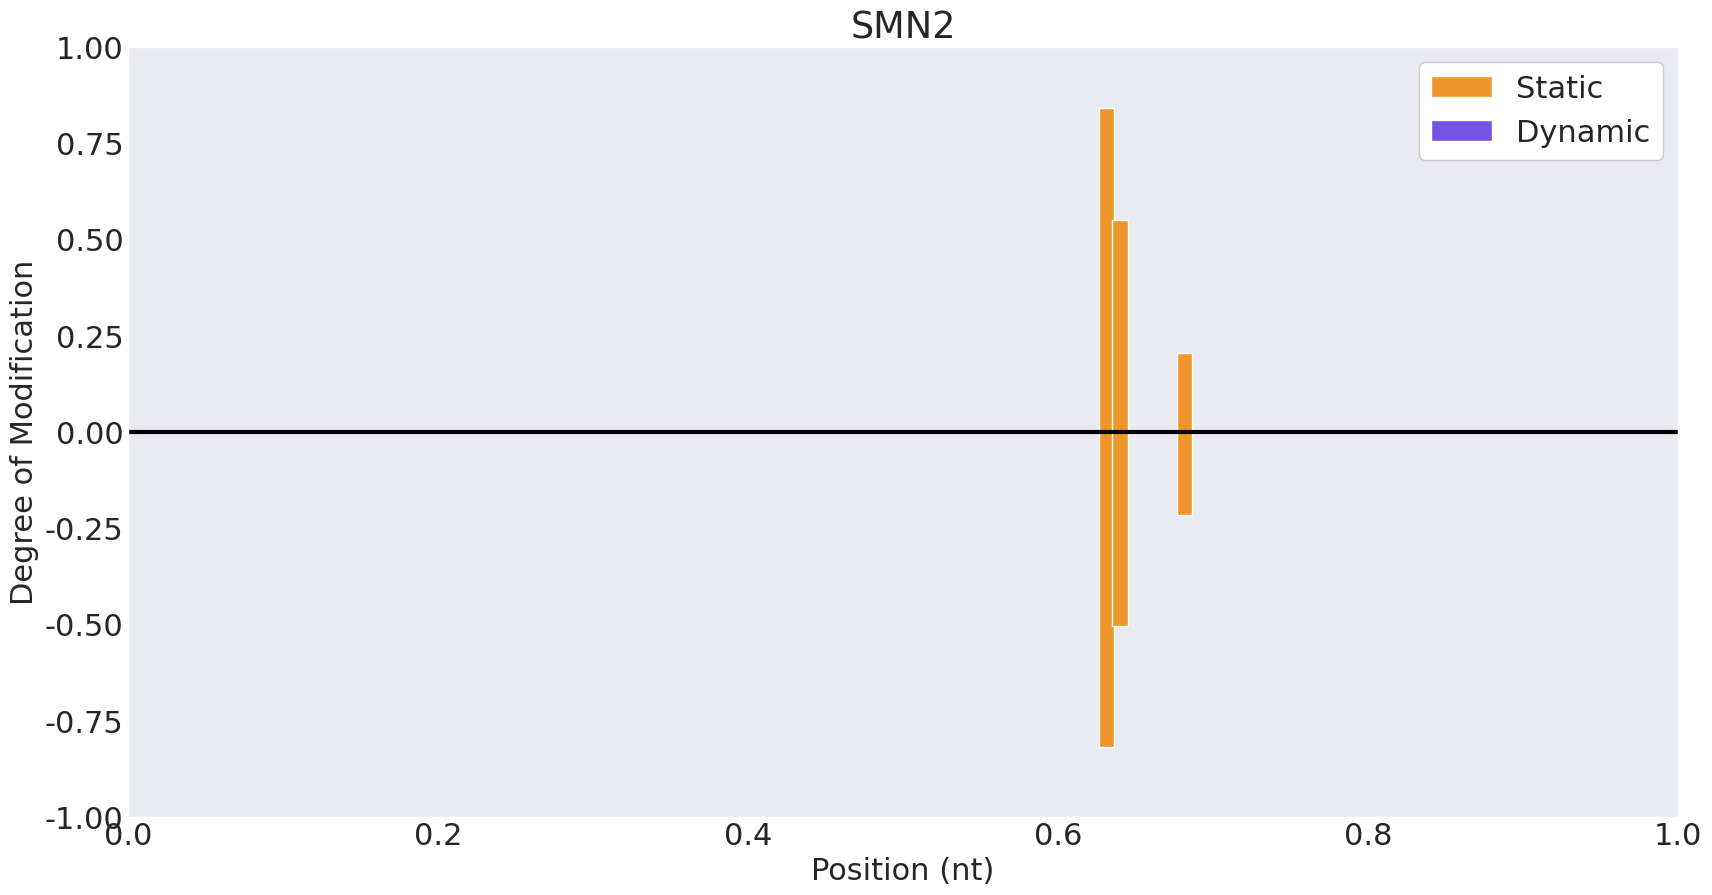

CAP1


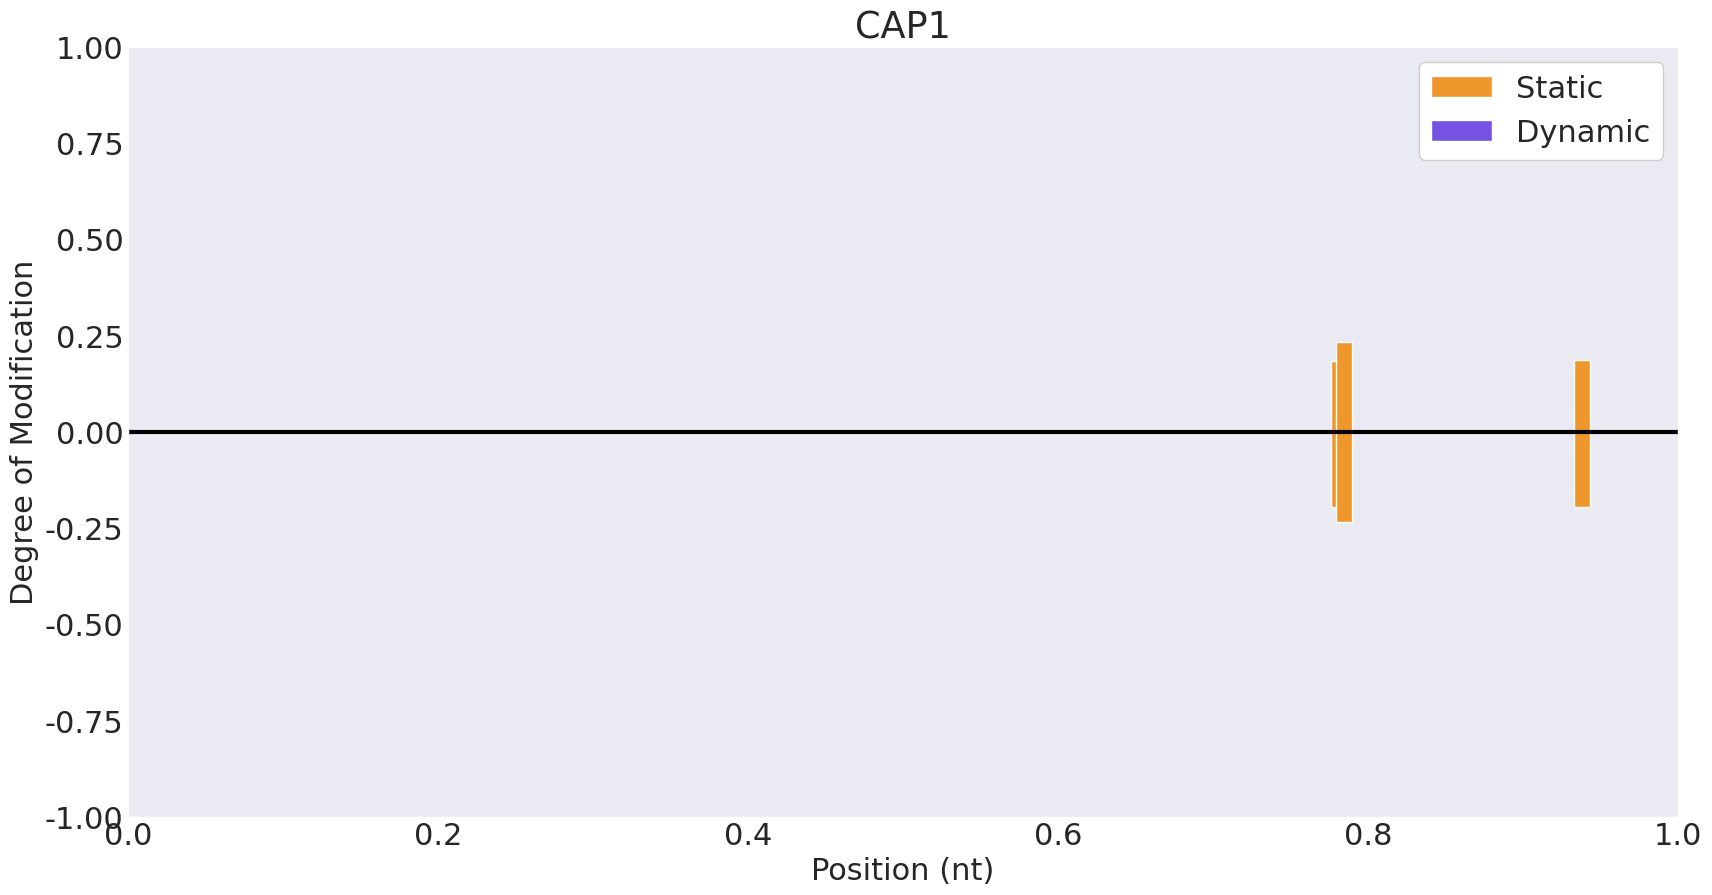

CLTC


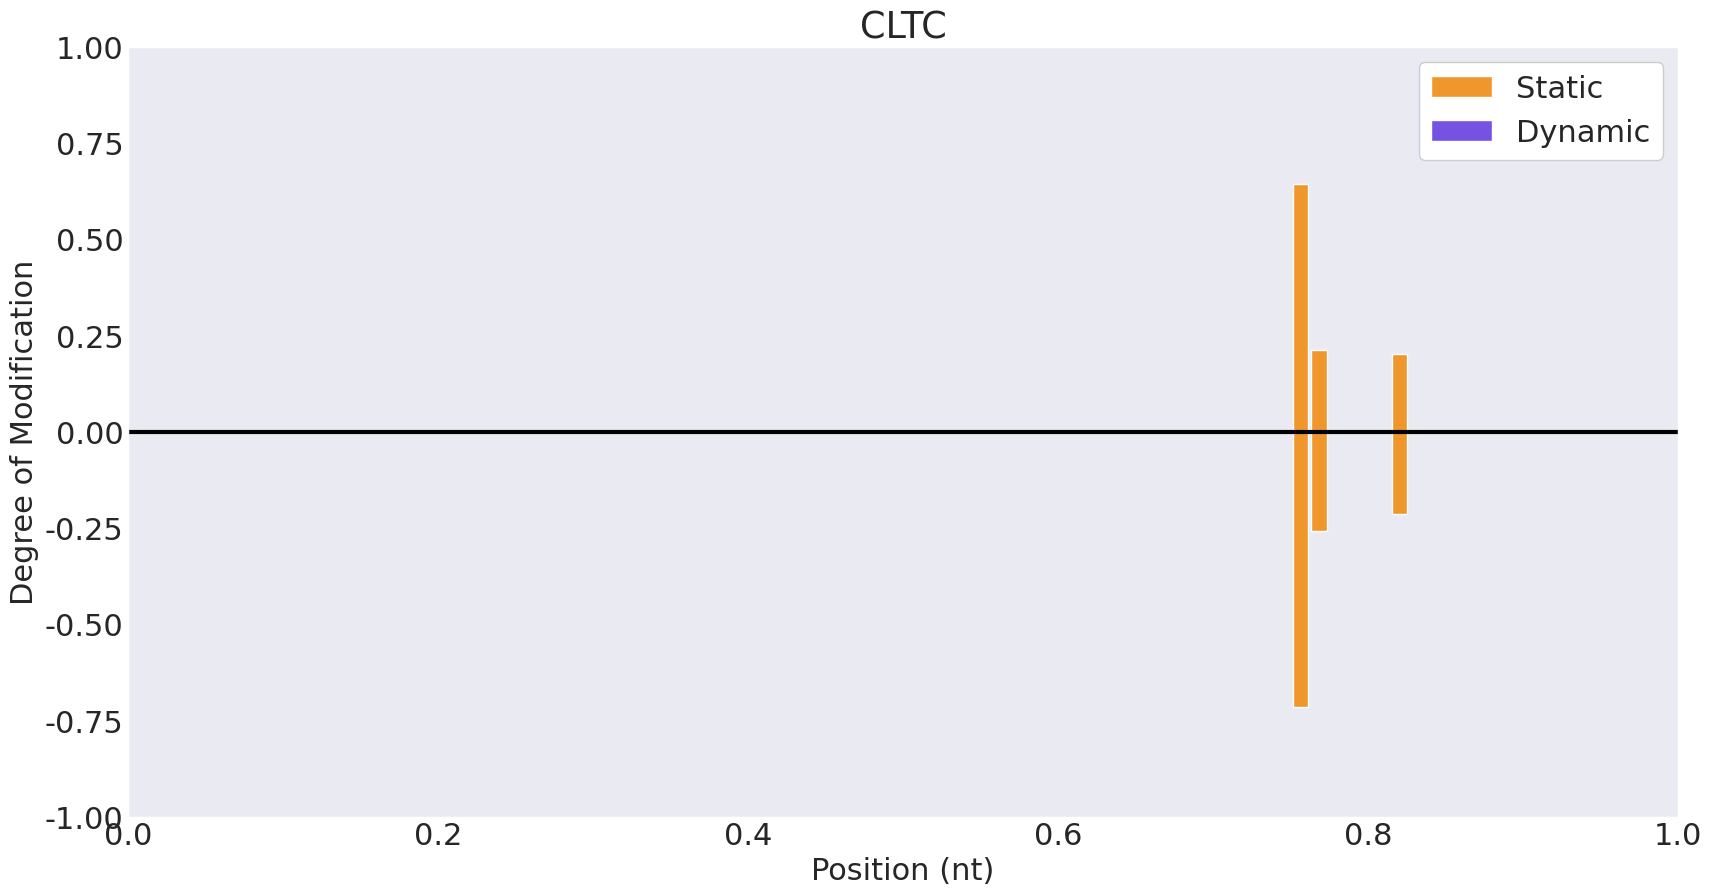

H2BC12


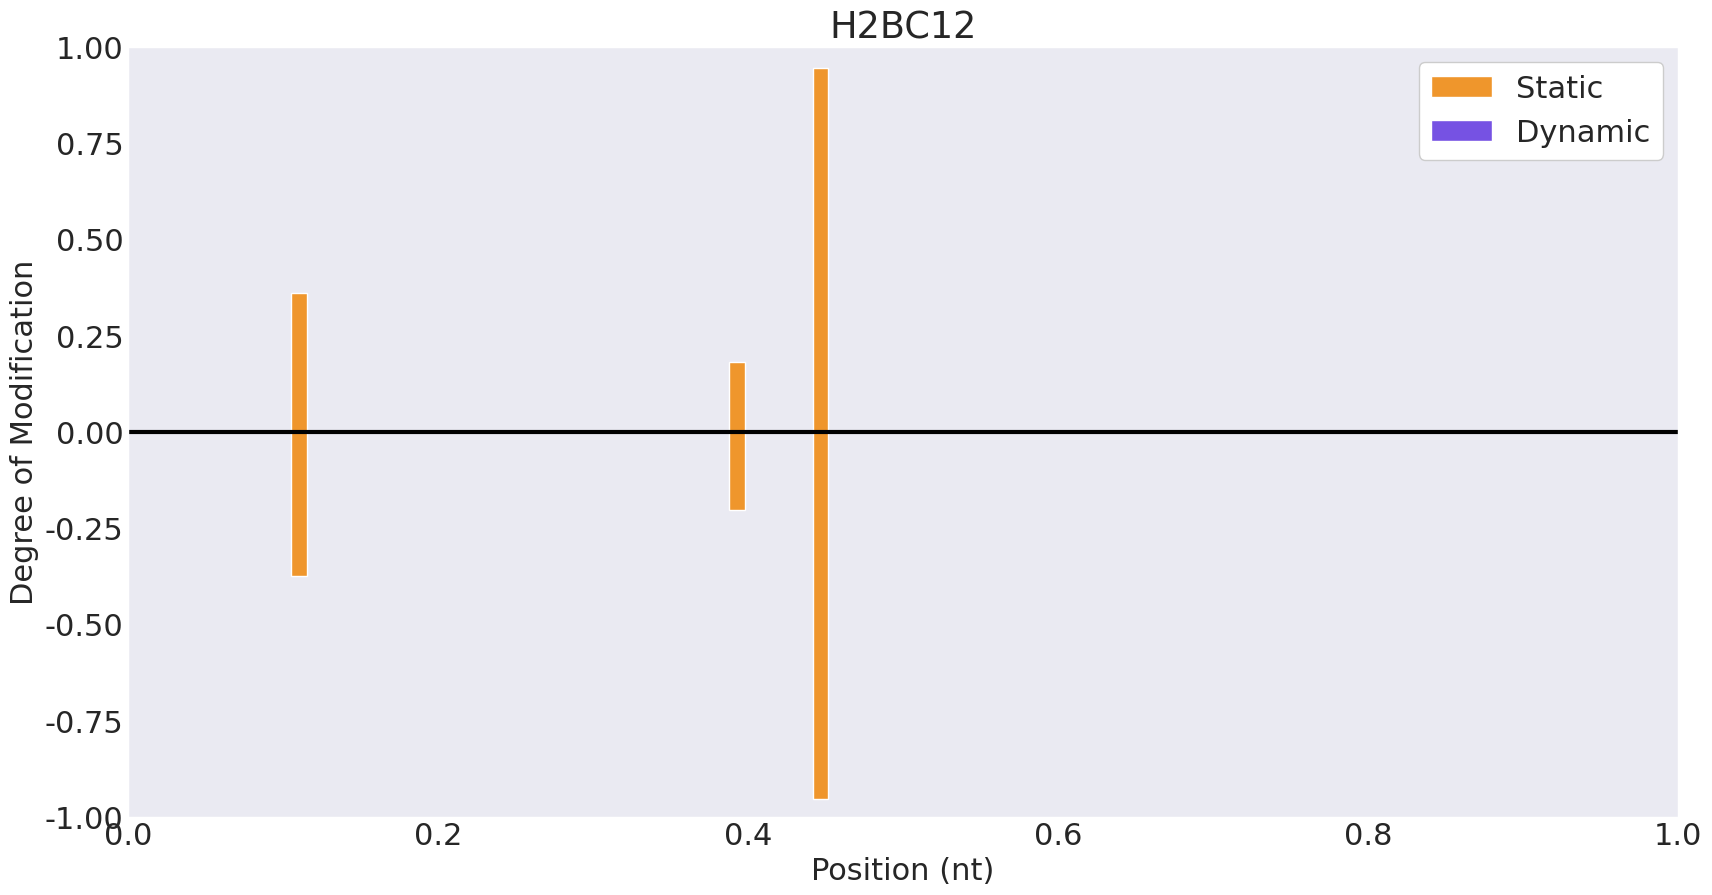

EIF2S3


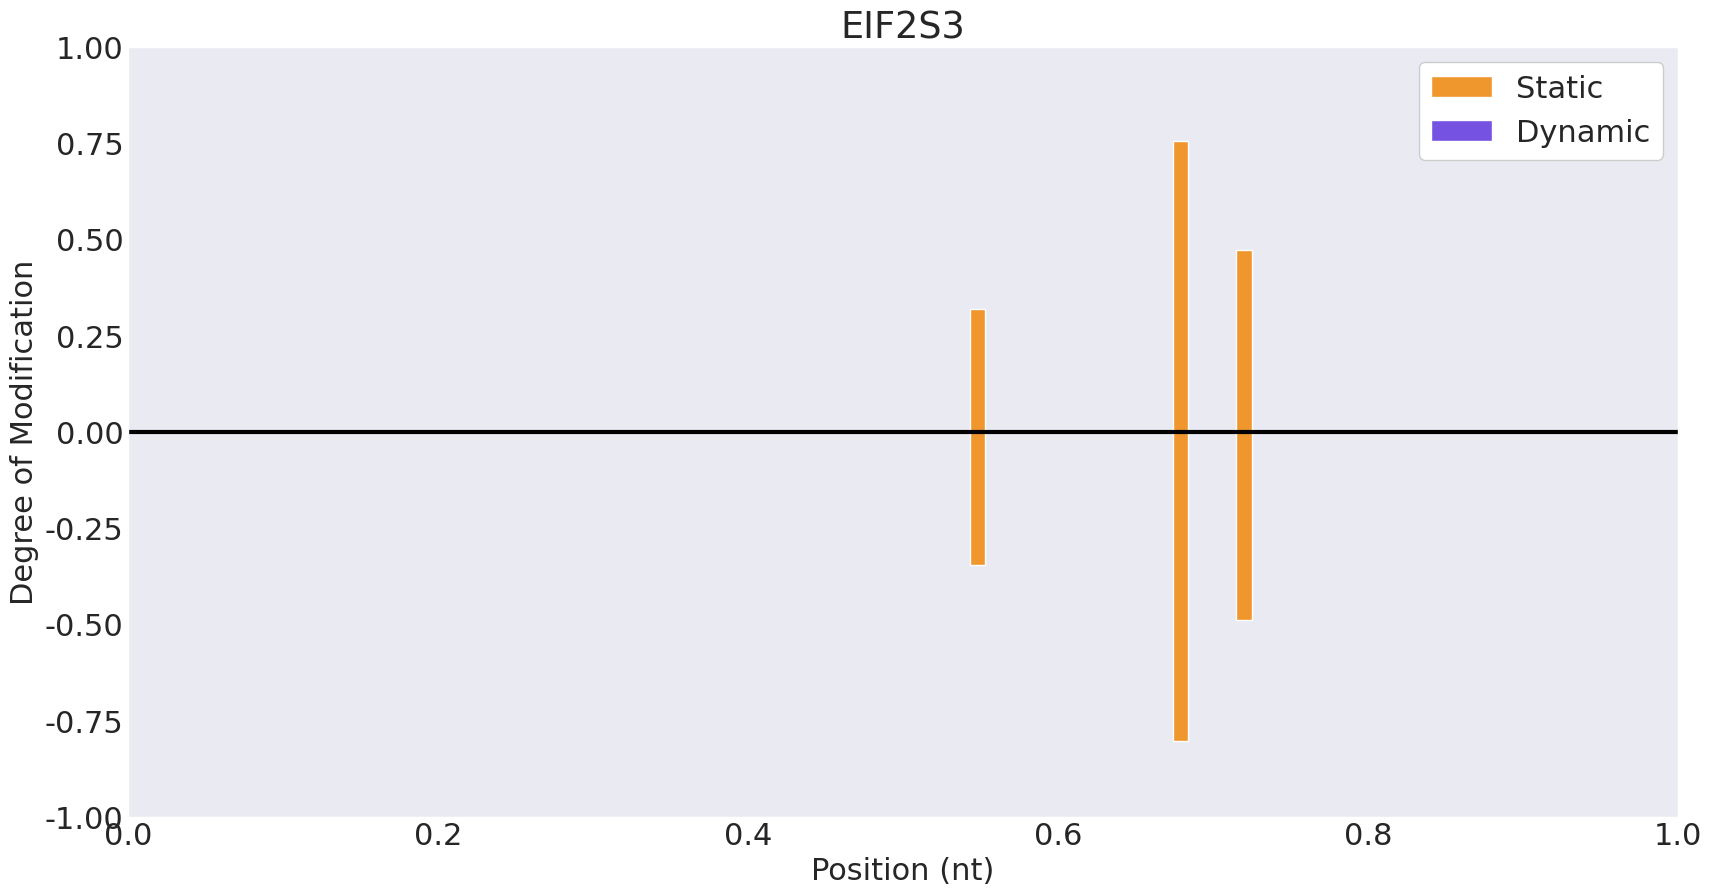

PRPF19


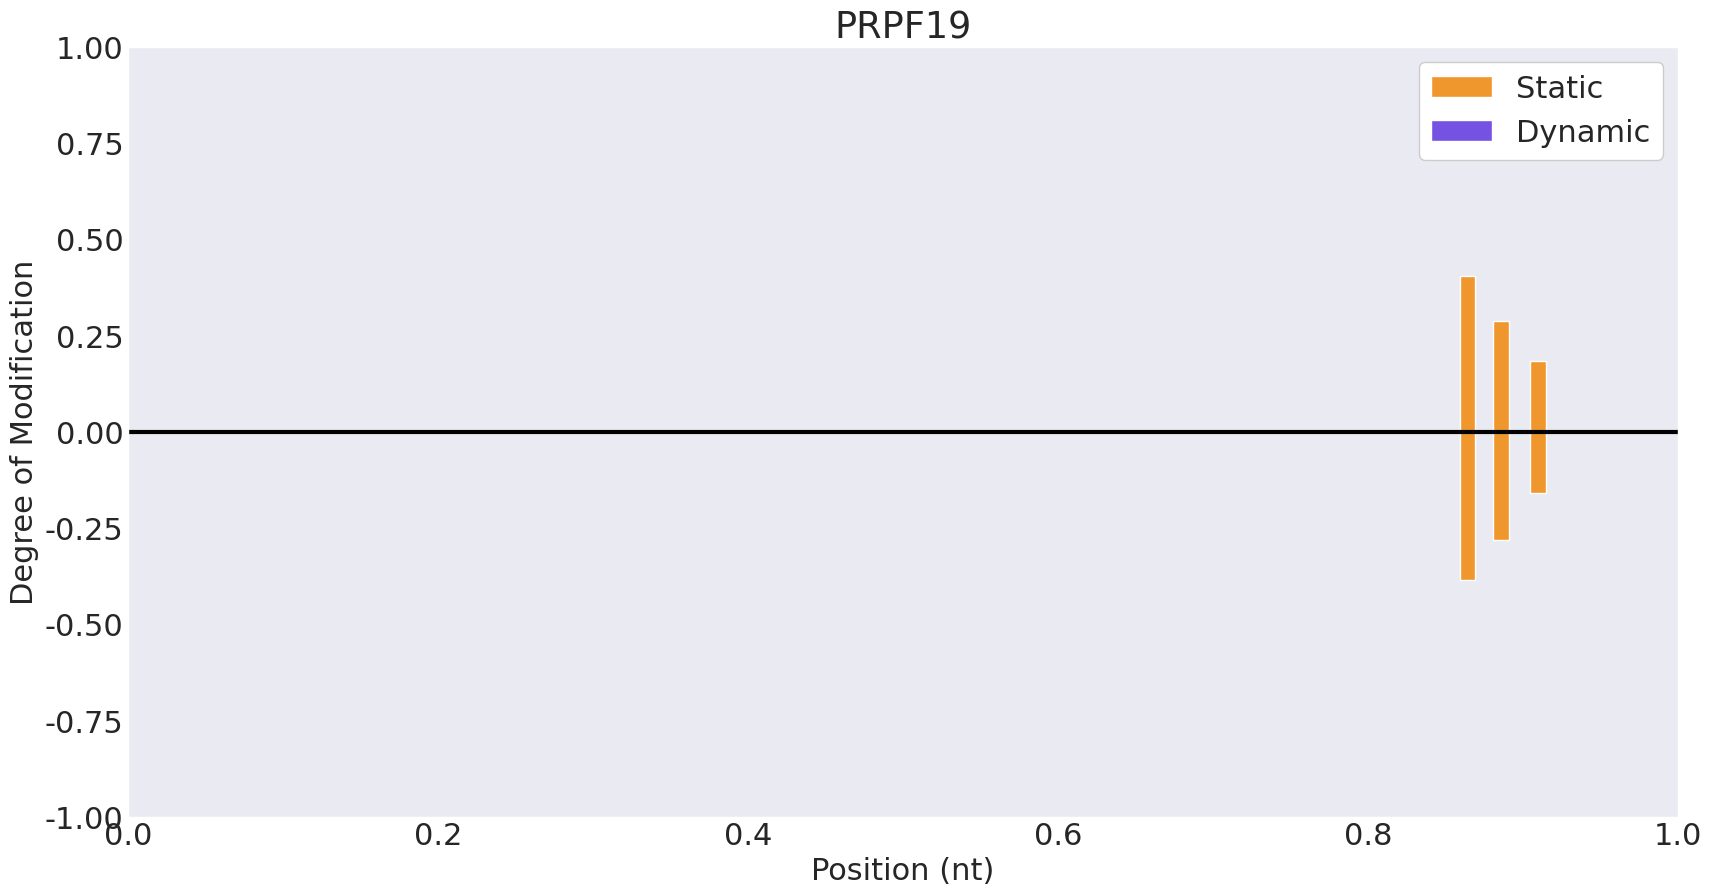

EPHX4


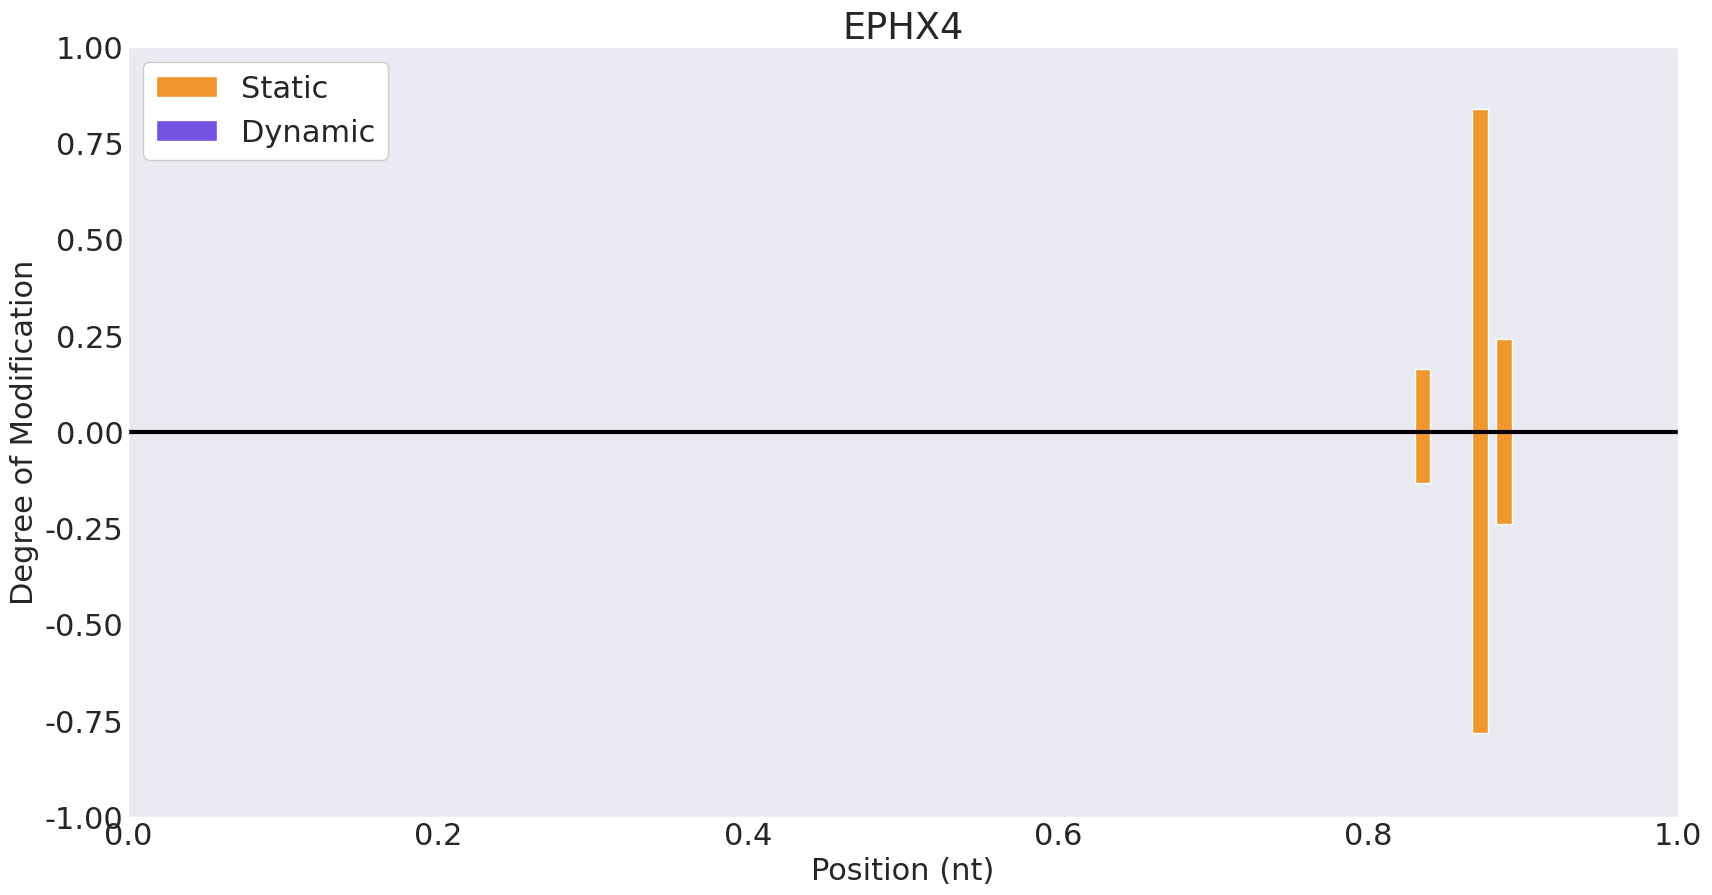

CLGN


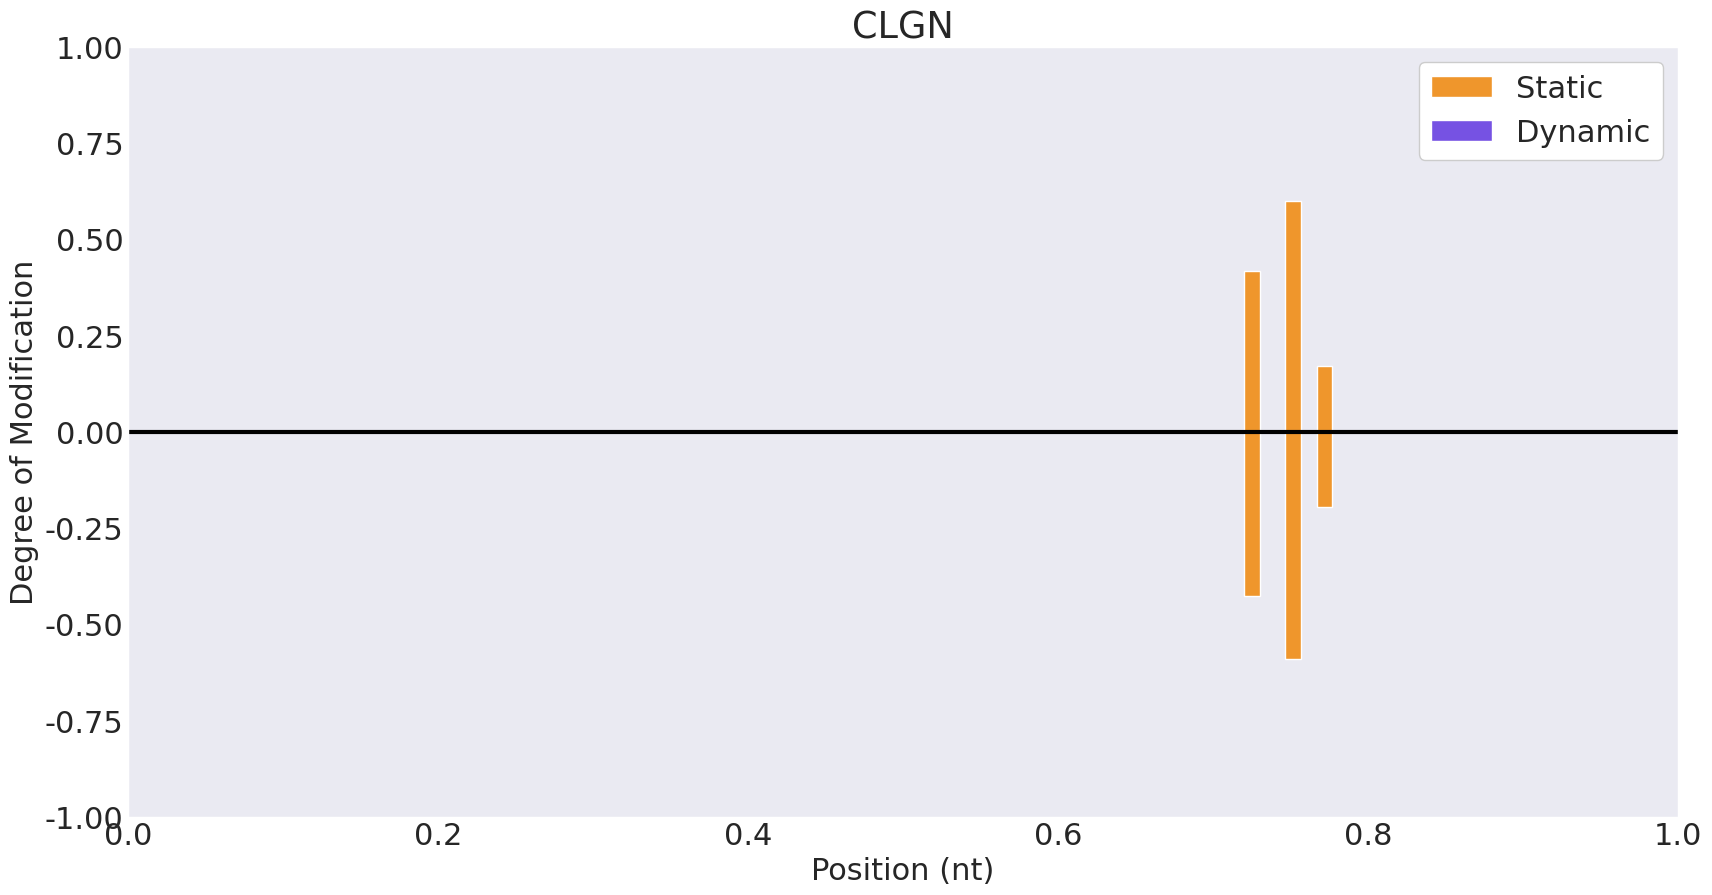

DNAJB14


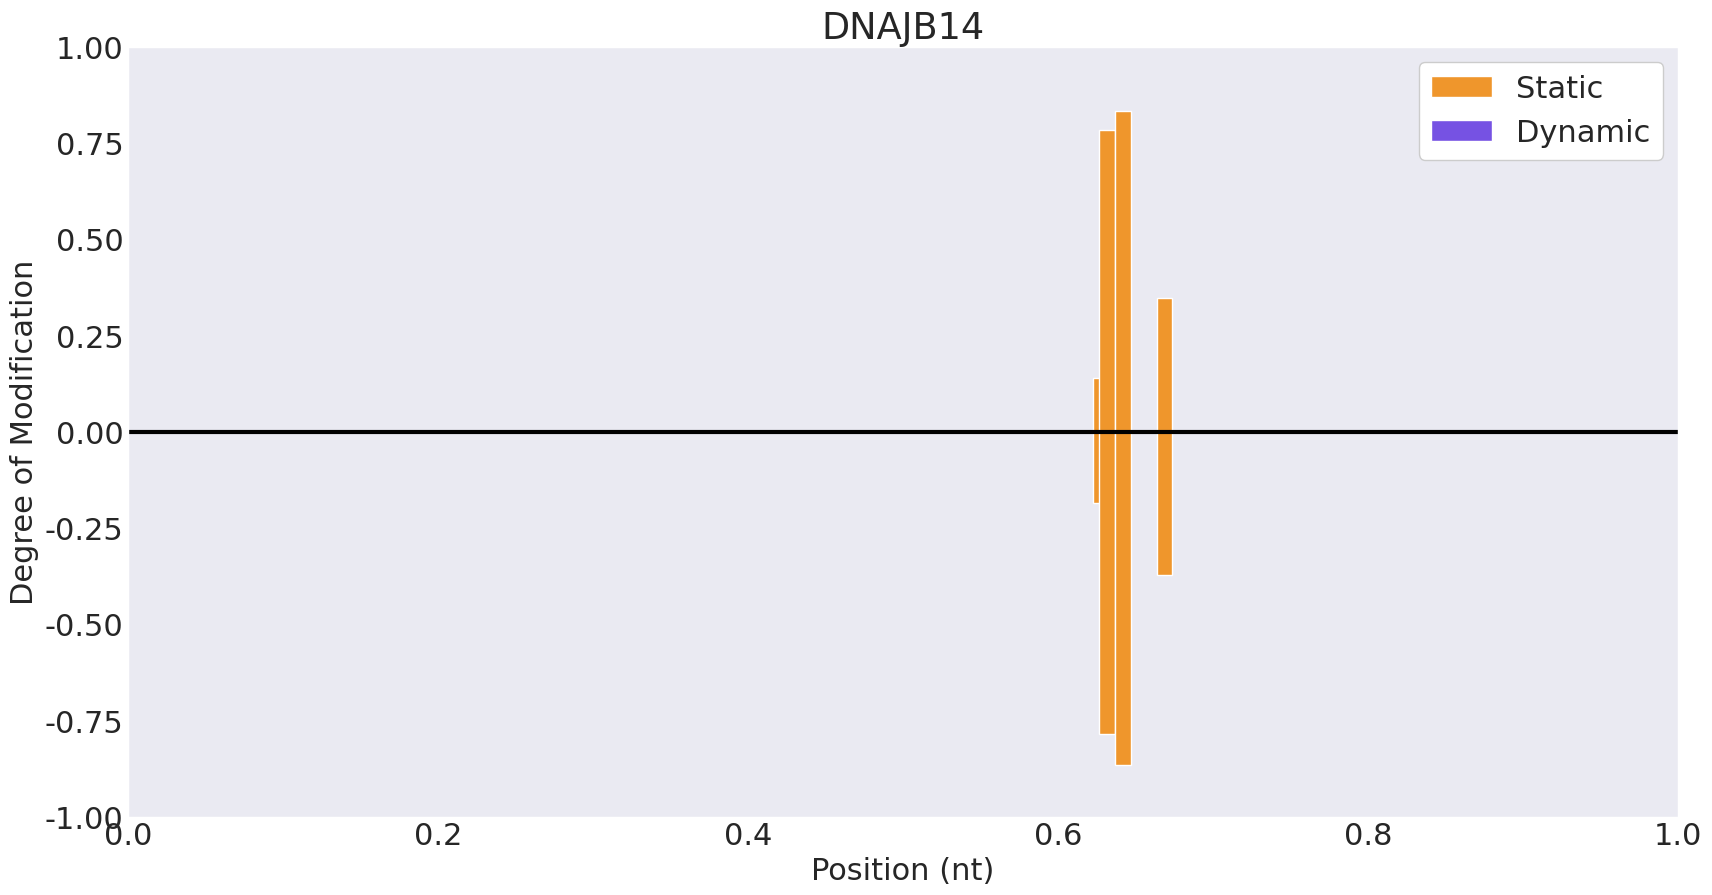

FECH


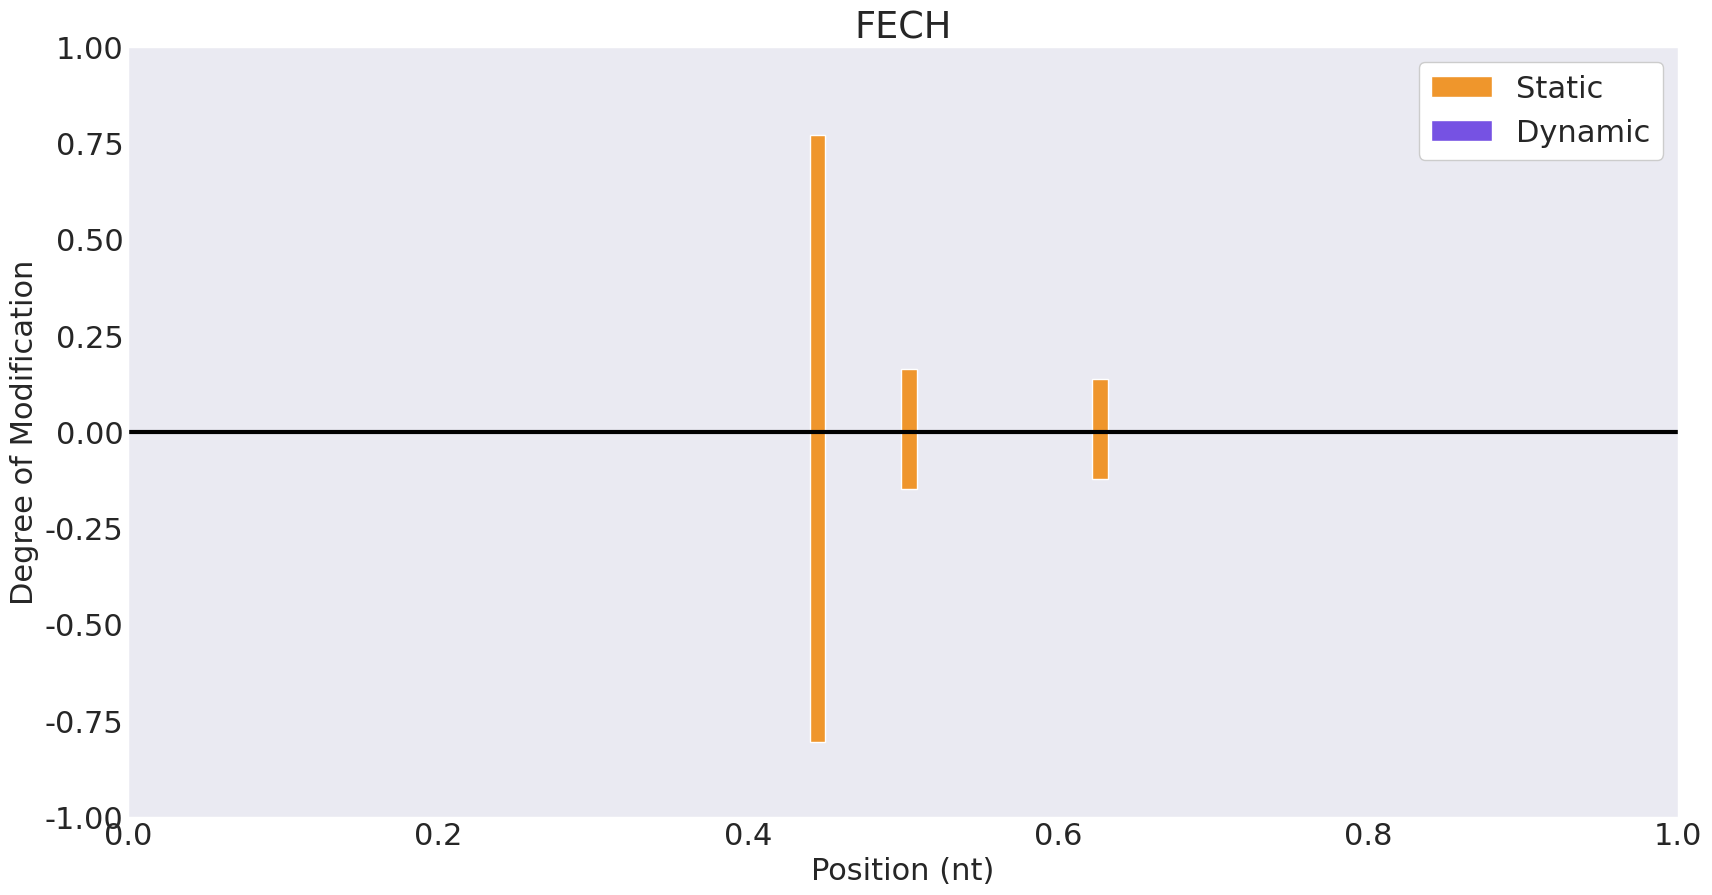

In [543]:
for gene_id in cosine_dist_dict[(cosine_dist_dict["site_count"] < 5) & (cosine_dist_dict["total_sites"] < 5)& (cosine_dist_dict["total_sites"] >=3)& (cosine_dist_dict["dist"] < 0.001)]["gene_id"].sample(10):
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="dynamic")

In [ ]:
for gene_id in cosine_dist_dict[(cosine_dist_dict["site_count"] >= 10) & (cosine_dist_dict["total_sites"] >= 10)]["gene_id"][30:60]:
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="dynamic", output = None)

In [ ]:
for gene_id in cosine_dist_dict[(cosine_dist_dict["site_count"] >= 10) & (cosine_dist_dict["total_sites"] >= 10)& (cosine_dist_dict["total_sites"] >= 5)& (cosine_dist_dict["dist"] < 0.003)]["gene_id"].sample(10):
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="dynamic")

In [484]:
alt_dist_list = []
for gene_id, a in tqdm.tqdm(dmg_dict.items()):
    a = a.T
    total_sites = np.sum(a[0]+a[1] > 0)
    diff_sites = np.sum((a[0] * a[1] == 0)&(a[0] + a[1] > 0))
    alt_dist_list.append((gene_id, diff_sites, total_sites))
    
alt_dist_dict = pd.DataFrame(alt_dist_list, columns=["gene_id", "dist", "total_sites"]).sort_values("dist", ascending=False)
print(alt_dist_dict)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11162/11162 [00:02<00:00, 5120.23it/s]

           gene_id  dist  total_sites
4551      KIAA1549    28           93
4990  LOC124901161    25           76
2302         DIDO1    24          101
4311          ING5    23           67
8917         SNX29    21           43
...            ...   ...          ...
7361         PSMB1     0            2
7362        PSMB10     0            0
7364         PSMB3     0            0
7365         PSMB4     0            1
7367         PSMB6     0            0

[11162 rows x 3 columns]


In [ ]:
for gene_id in alt_dist_dict[alt_dist_dict["total_sites"]>=10].head(10)["gene_id"]:
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="dynamic", output = None)

In [ ]:
for gene_id in [
    "ENSG00000306316",
    "ADD3",
    "ARHGAP33",
    "RNASEH1",
    "INO80E",
    "EIF2B2",
    "RELCH",
    "GANC",
    "STAC",
    "TRNP1",
    "RAC2",
    "PIM2",
    "TLE1",
    "SLC2A11",
]:    
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="cell")

In [ ]:
nondrach_alt_dist_list = []
for gene_id, a in tqdm.tqdm(dmg_dict.items()):
    a = a[a[:,3] == 0].T
    total_sites = np.sum(a[0]+a[1] > 0)
    a = a[:,a[0]+a[1] > 0]
    diff = (((a[0] - a[1]) ** 2).sum())**0.5 / total_sites
    nondrach_alt_dist_list.append((gene_id, diff, total_sites))

nondrach_alt_dist_dict = pd.DataFrame(nondrach_alt_dist_list, columns=["gene_id", "dist", "total_sites"]).sort_values("dist", ascending=False)
print(nondrach_alt_dist_dict)

In [ ]:
for gene_id in nondrach_alt_dist_dict[nondrach_alt_dist_dict["total_sites"]>=3].head(50)["gene_id"]:
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="drach", output = None)

In [517]:
## Find genes only modified in HeLa
hek_only = []
for gene_id, a in tqdm.tqdm(dmg_dict.items()):
    a = a.T
    if np.sum(a[0]) == 0 and np.sum(a[1]) > 0.7:
        hek_only.append(gene_id)
print(hek_only)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11162/11162 [00:00<00:00, 39124.12it/s]

['ARHGAP27P1-BPTFP1-KPNA2P3', 'ENSG00000310416', 'FBXO44', 'LCAT', 'MIR3916', 'SCX', 'SGSM3', 'VASP']


In [499]:
print(np.sum(hela_df_groupby_gene.get_group("LCAT")["pm6a"] > hela_fdr_threshold))
print(np.sum(hek_df_groupby_gene.get_group("LCAT")["pm6a"] > hek_fdr_threshold))

3
0


In [521]:
print(np.sum(hela_df_groupby_gene.get_group("FBXO44")["pm6a"] > hela_fdr_threshold))
print(np.sum(hek_df_groupby_gene.get_group("FBXO44")["pm6a"] > hek_fdr_threshold))

5
1


In [512]:
print(hek_df_groupby_gene.get_group("SCX")[hek_df_groupby_gene.get_group("SCX")["pm6a"] > hek_fdr_threshold])

Empty DataFrame
Columns: [genome_id, gene_id, coding, drach, isoforms, pm6a, dom, count_all, chr, strand, genome_pos, dmgval]
Index: []


In [495]:
## Find genes only modified in HeLa
hek_only = []
for gene_id, a in tqdm.tqdm(dmg_dict.items()):
    a = a.T
    if np.sum(a[0]) > 1 and np.sum(a[1]) == 0:
        hek_only.append(gene_id)
print(hek_only)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11162/11162 [00:00<00:00, 28148.93it/s]

['ADCK5']


ACBD6


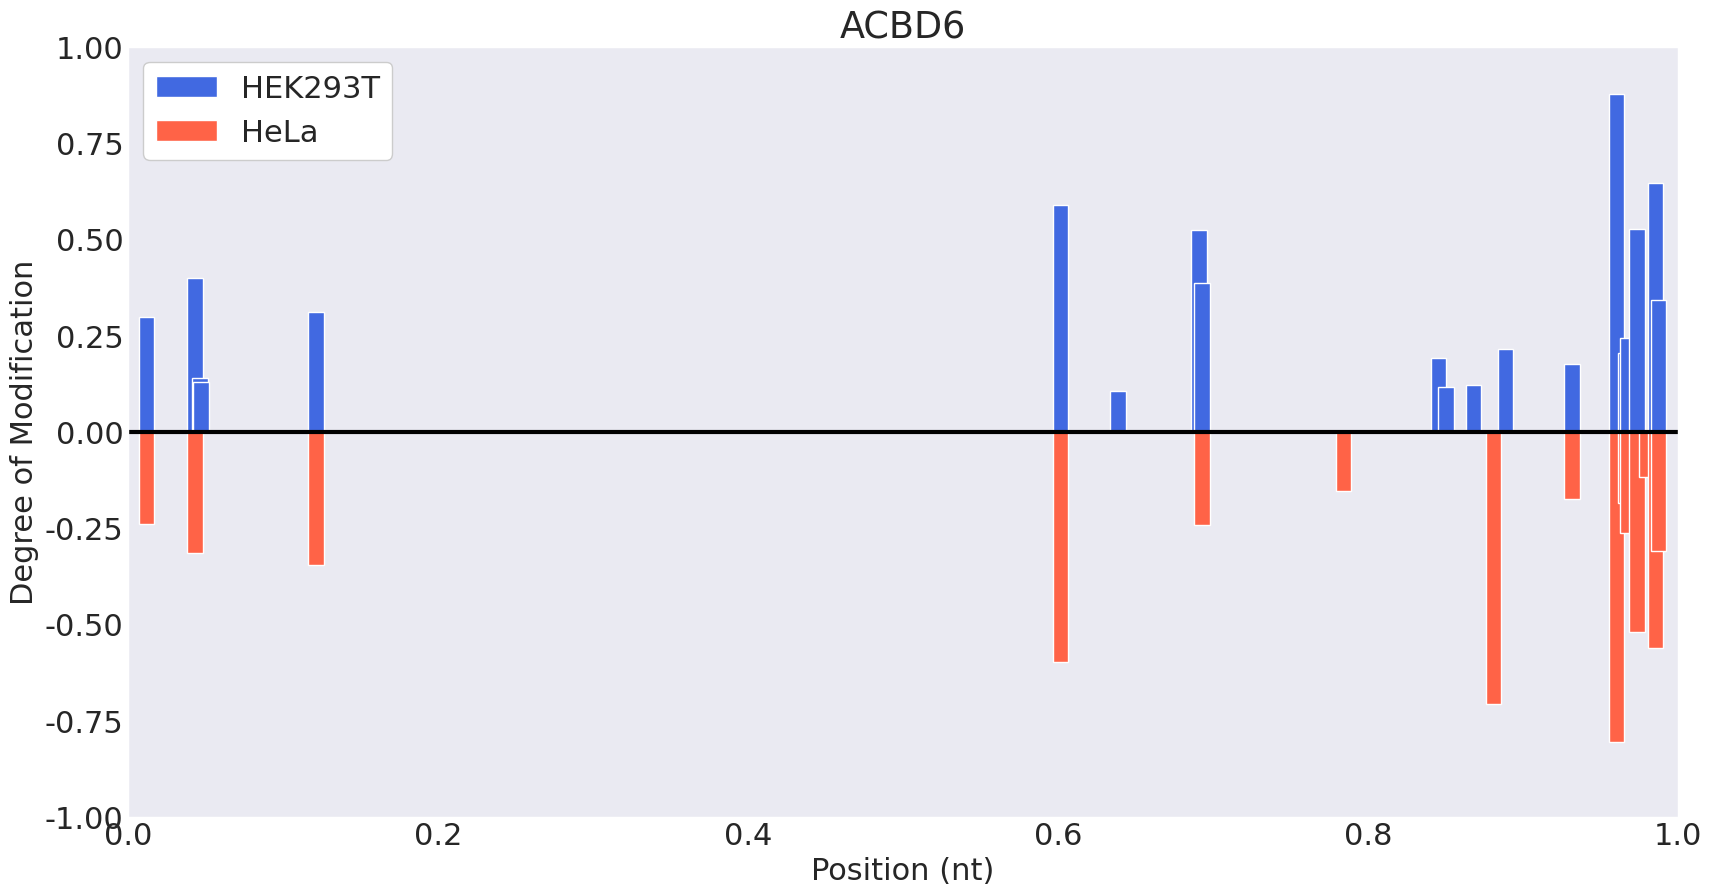

In [525]:
for gene_id in ['ACBD6']:
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="cell")

In [532]:
diffsite_dict = {}
for gene_id in dmg_dict.keys():
    a = dmg_dict[gene_id].T
    c = ((a[0]*a[1] == 0) & (a[0] + a[1] > 0)).sum()
    diffsite_dict[gene_id] = c
diffsite_df = pd.DataFrame(diffsite_dict.items(), columns=["gene_id", "diffsite"]).sort_values("diffsite", ascending=False)
print(diffsite_df)
    

           gene_id  diffsite
4551      KIAA1549        28
4990  LOC124901161        25
2302         DIDO1        24
4311          ING5        23
8917         SNX29        21
...            ...       ...
7361         PSMB1         0
7362        PSMB10         0
7364         PSMB3         0
7365         PSMB4         0
7367         PSMB6         0

[11162 rows x 2 columns]


In [ ]:
for gene_id in diffsite_df[diffsite_df["diffsite"] > 0].head(10)["gene_id"]:
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="dynamic", output = None)

EIF2S3


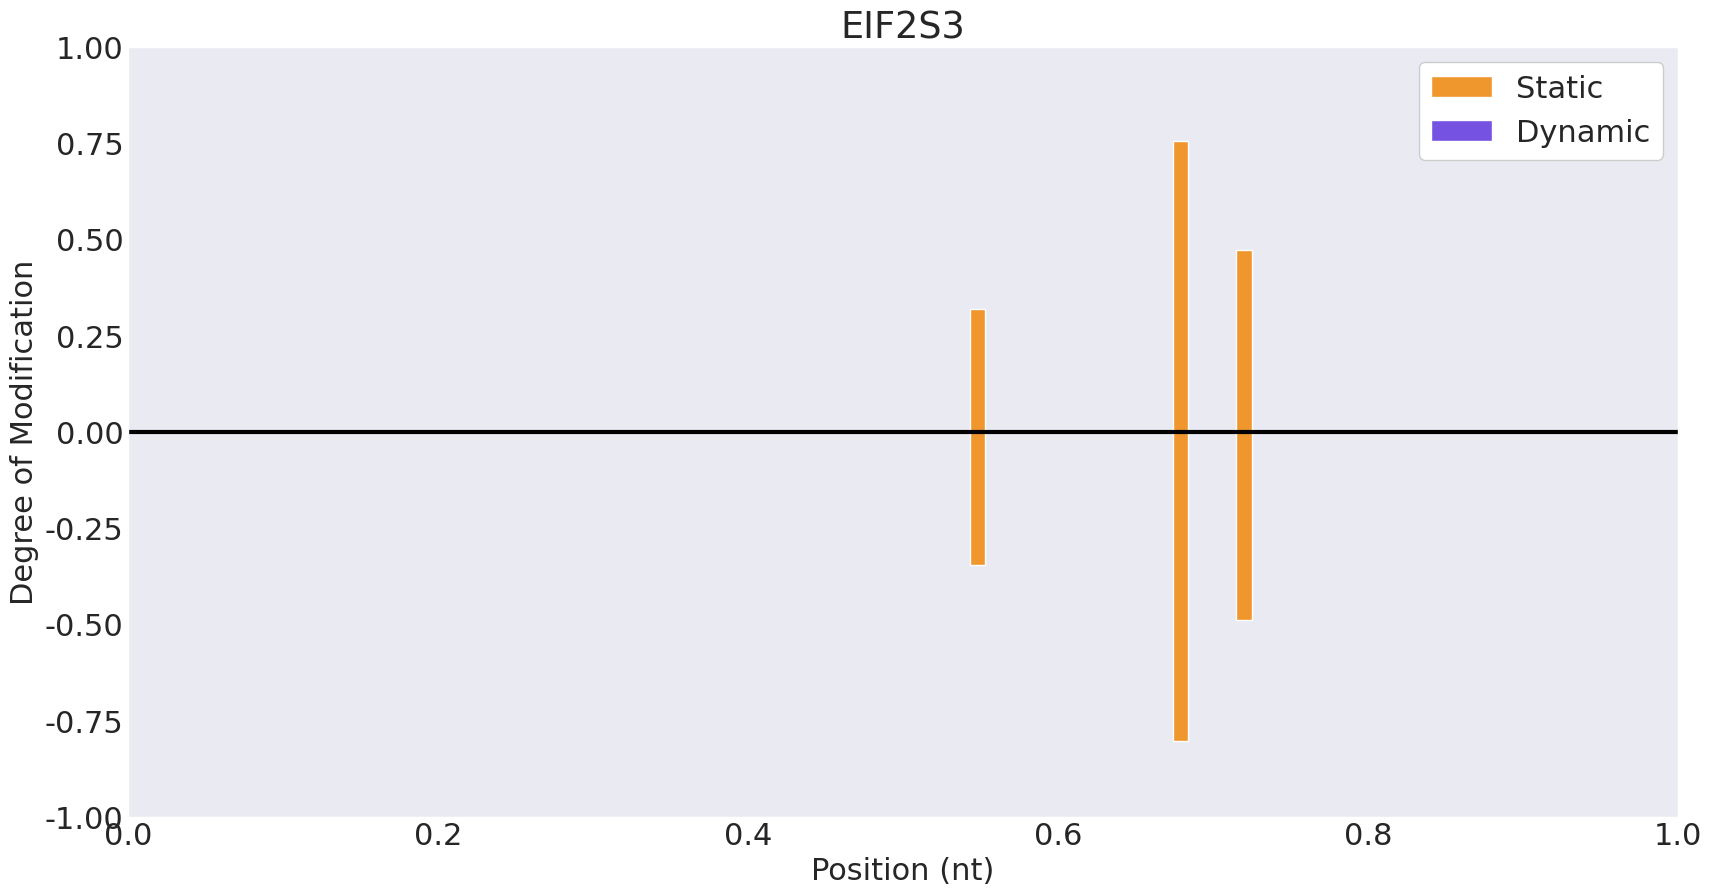

In [544]:
for gene_id in ["EIF2S3"]:
    print(gene_id)
    plot_dmg_arr(id_to_name_dict[gene_id], dmg_dict[gene_id], colour="dynamic")
    

In [537]:
print(diffsite_df[diffsite_df["gene_id"] == "ZNF436"])

      gene_id  diffsite
10958  ZNF436        16
